# Lab 6: Keras MLP for Regression

**Objective:** Implement a Multi-Layer Perceptron (MLP) using Keras/TensorFlow for a regression problem, and analyze the effect of different activation functions and loss functions on model performance.

## 1. Dataset Description & Source

**Dataset:** Vehicle Dataset from CarDekho ([Kaggle: nehalbirla/vehicle-dataset-from-cardekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)), specifically the `car data.csv` file — 301 used-car listings from the Indian resale market.

- **Target variable (continuous):** `Selling_Price` — the car's resale price in ₹ Lakhs
- **Input features:** `Present_Price` (original showroom price), `Kms_Driven`, `Fuel_Type`, `Seller_Type`, `Transmission`, `Owner`, `Year`

**Why this dataset:** predicting resale value from a car's condition and specs is a real-world regression problem — it's the same thing "instant valuation" tools on car resale sites do.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")
print("Dataset downloaded to:", path)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/keshav12/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [ ]:
csv_path = os.path.join(path, "car data.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.head())

Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


## 2. Data Preprocessing

- **Missing values:** none (checked above)
- **`Year` → `Car_Age`:** a car's age matters more to resale value than the raw year number
- **`Car_Name` dropped:** ~300 different names for 301 rows won't help the model generalize
- **One-hot encoding:** turns the text columns (`Fuel_Type`, `Seller_Type`, `Transmission`) into 0/1 numeric columns
- **Feature scaling:** `StandardScaler` so every feature is on the same scale (important for MLPs)
- **Split:** 80% train, 20% test

In [6]:
df['Car_Age'] = 2020 - df['Year']
df = df.drop(['Car_Name', 'Year'], axis=1)

df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price'].values

print("Features used:", list(X.columns))

Features used: ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Test samples:", X_test_scaled.shape[0])

Training samples: 240
Test samples: 61


## 3. Understanding the Target Variable

Before choosing an activation function or a loss function, it helps to actually look at what we're
trying to predict — the choice shouldn't just be "try the usual defaults", it should follow from
what the data looks like.

In [8]:
print(df['Selling_Price'].describe())
print()
print("Skew:", round(df['Selling_Price'].skew(), 2))
print("Median price: Rs", df['Selling_Price'].median(), "Lakh")
print("Max price   : Rs", df['Selling_Price'].max(), "Lakh")
print("Max is", round(df['Selling_Price'].max() / df['Selling_Price'].median(), 1), "times the median")

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

Skew: 2.49
Median price: Rs 3.6 Lakh
Max price   : Rs 35.0 Lakh
Max is 9.7 times the median


**What this tells us:**
- The median selling price is ₹3.6 Lakh, but the most expensive car in the dataset is ₹35 Lakh —
  almost **10x the median**. A skew of **2.49** confirms this: the distribution has a long right
  tail of a small number of expensive cars, not a symmetric spread around the average.
- Only 240 rows go into training. With this little data, the model doesn't get many chances to see
  an expensive car, so how it's trained to react to large errors on those rare cases matters more
  than it would on a bigger, more evenly spread dataset.

This is exactly the situation that's normally used to argue for MAE or Huber loss over plain MSE
(Section 5) — a few high-value outliers that MSE's squared penalty could over-react to. Whether that
holds up in practice, for this specific dataset and training setup, is what Experiment 2 tests.

## 4. MLP Architecture

Every model below uses the exact same architecture:

- **Input layer:** 8 features
- **3 hidden Dense layers:** 64 → 32 → 16 neurons
- **Output layer:** 1 neuron, no activation (linear) — because price is a continuous number, not a class

Only the **activation function** (used in the 3 hidden layers) and the **loss function** change between the 5 models below. Everything else — architecture, optimizer, learning rate, epochs, batch size, train/test split — is kept exactly the same, so any difference in results is caused by that one change.

## 5. Experiment 1 — Activation Function Comparison

Loss is kept fixed at **MSE** for all three models below, so their loss curves are on the same scale and can be compared directly.

**Why these three functions matter specifically for *this* setup, not just in general:**
- Only **240 training rows** are available, so the model has a limited, fixed number of epochs (100) to
  learn from — an activation whose gradient shrinks toward 0 for large inputs (Sigmoid, Tanh) simply
  has less room to recover from that slow start than one that doesn't (ReLU).
- The inputs were deliberately **zero-centered by `StandardScaler`** (Section 2) specifically so the
  network trains better — ReLU's threshold sits exactly at 0, so it splits scaled input values into
  "on" and "off" the way it's meant to. Sigmoid/Tanh don't get any extra benefit from zero-centered
  inputs the way ReLU does.
- The network is **3 hidden layers deep**. Each saturating layer (Sigmoid/Tanh) multiplies a
  small gradient into the next layer's gradient, so the vanishing-gradient problem compounds with
  depth — a bigger risk here than it would be for a single-hidden-layer network.

Based on this, the hypothesis is that **ReLU should train faster and end up more accurate** than
Sigmoid or Tanh on this dataset — tested below.

- **ReLU** — outputs 0 for negative inputs, and the input itself for positive inputs. Cheap to compute and doesn't suffer from vanishing gradients.
- **Sigmoid** — squashes output between 0 and 1. For large positive or negative inputs, its gradient becomes almost 0, which can slow down learning.
- **Tanh** — squashes output between -1 and 1. Similar saturation problem as Sigmoid, but zero-centered.

In [ ]:
tf.keras.utils.set_random_seed(42)

model1 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # linear output for regression
])

model1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

history1 = model1.fit(X_train_scaled, y_train, validation_split=0.2,
                       epochs=100, batch_size=8, verbose=0)

pred1 = model1.predict(X_test_scaled, verbose=0).flatten()

mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
r2_1 = r2_score(y_test, pred1)

print("Model 1 (ReLU + MSE)")
print("Test MAE :", round(mae1, 4))
print("Test RMSE:", round(rmse1, 4))
print("Test R2  :", round(r2_1, 4))

Model 1 (ReLU + MSE)
Test MAE : 0.6944
Test RMSE: 1.0147
Test R2  : 0.9553


In [ ]:
tf.keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(16, activation='sigmoid'),
    layers.Dense(1)
])

model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

history2 = model2.fit(X_train_scaled, y_train, validation_split=0.2,
                       epochs=100, batch_size=8, verbose=0)

pred2 = model2.predict(X_test_scaled, verbose=0).flatten()

mae2 = mean_absolute_error(y_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
r2_2 = r2_score(y_test, pred2)

print("Model 2 (Sigmoid + MSE)")
print("Test MAE :", round(mae2, 4))
print("Test RMSE:", round(rmse2, 4))
print("Test R2  :", round(r2_2, 4))

Model 2 (Sigmoid + MSE)
Test MAE : 0.9241
Test RMSE: 1.2622
Test R2  : 0.9308


In [ ]:
tf.keras.utils.set_random_seed(42)

model3 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(16, activation='tanh'),
    layers.Dense(1)
])

model3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

history3 = model3.fit(X_train_scaled, y_train, validation_split=0.2,
                       epochs=100, batch_size=8, verbose=0)

pred3 = model3.predict(X_test_scaled, verbose=0).flatten()

mae3 = mean_absolute_error(y_test, pred3)
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))
r2_3 = r2_score(y_test, pred3)

print("Model 3 (Tanh + MSE)")
print("Test MAE :", round(mae3, 4))
print("Test RMSE:", round(rmse3, 4))
print("Test R2  :", round(r2_3, 4))

Model 3 (Tanh + MSE)
Test MAE : 1.0304
Test RMSE: 1.6275
Test R2  : 0.885


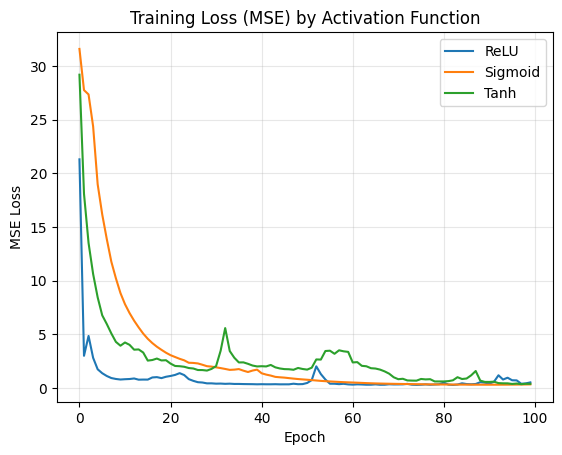

In [ ]:
plt.plot(history1.history['loss'], label='ReLU')
plt.plot(history2.history['loss'], label='Sigmoid')
plt.plot(history3.history['loss'], label='Tanh')
plt.title('Training Loss (MSE) by Activation Function')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

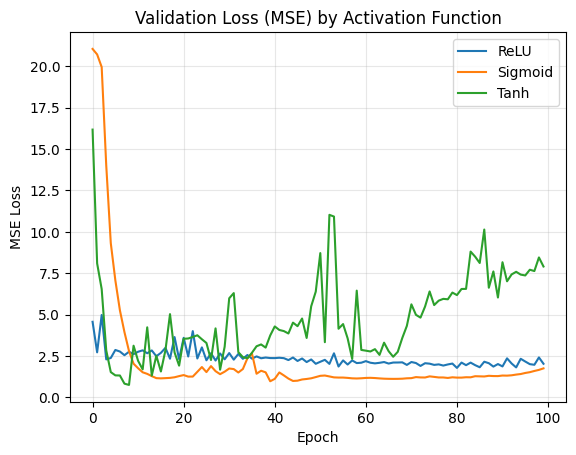

In [ ]:
plt.plot(history1.history['val_loss'], label='ReLU')
plt.plot(history2.history['val_loss'], label='Sigmoid')
plt.plot(history3.history['val_loss'], label='Tanh')
plt.title('Validation Loss (MSE) by Activation Function')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Experiment 2 — Loss Function Comparison

Activation is kept fixed at **ReLU** (the best one from Experiment 1) for all three models below. Model 1 (ReLU + MSE) from above is reused as the first row of this comparison too, so only 2 new models need to be trained here.

**Why these three losses matter specifically for *this* dataset:** Section 3 showed a skew of 2.49
and a max price almost 10x the median — a small number of expensive cars sitting well outside the
typical ₹0.9–6 Lakh range (the 25th–75th percentile band from `describe()`). That's the textbook
case for MSE to misbehave: squaring the error on those few expensive cars produces a much larger
loss value than the same relative mistake on a cheap car, so the model could end up prioritizing
those outliers over getting the (much more common) cheap cars right. MAE and Huber are the standard
answer to exactly this scenario, since they don't square the error.

- **MSE (Mean Squared Error)** — squares each error, so bigger mistakes are punished much more. Sensitive to outliers.
- **MAE (Mean Absolute Error)** — treats every error the same way (no squaring), so a few outliers don't dominate training. Easy to interpret since it's in the same unit (₹ Lakh) as the price.
- **Huber Loss** — behaves like MSE for small errors and like MAE for large errors, meant to combine the benefits of both.

Given the skew, the hypothesis is that **MAE or Huber should outperform MSE**, especially on the
priciest cars specifically — tested below, including a dedicated check on just those cars in Section 7.

In [ ]:
tf.keras.utils.set_random_seed(42)

model4 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mae', metrics=['mae'])

history4 = model4.fit(X_train_scaled, y_train, validation_split=0.2,
                       epochs=100, batch_size=8, verbose=0)

pred4 = model4.predict(X_test_scaled, verbose=0).flatten()

mae4 = mean_absolute_error(y_test, pred4)
rmse4 = np.sqrt(mean_squared_error(y_test, pred4))
r2_4 = r2_score(y_test, pred4)

print("Model 4 (ReLU + MAE)")
print("Test MAE :", round(mae4, 4))
print("Test RMSE:", round(rmse4, 4))
print("Test R2  :", round(r2_4, 4))

Model 4 (ReLU + MAE)
Test MAE : 0.6334
Test RMSE: 0.9306
Test R2  : 0.9624


In [ ]:
tf.keras.utils.set_random_seed(42)

model5 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model5.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss=keras.losses.Huber(), metrics=['mae'])

history5 = model5.fit(X_train_scaled, y_train, validation_split=0.2,
                       epochs=100, batch_size=8, verbose=0)

pred5 = model5.predict(X_test_scaled, verbose=0).flatten()

mae5 = mean_absolute_error(y_test, pred5)
rmse5 = np.sqrt(mean_squared_error(y_test, pred5))
r2_5 = r2_score(y_test, pred5)

print("Model 5 (ReLU + Huber)")
print("Test MAE :", round(mae5, 4))
print("Test RMSE:", round(rmse5, 4))
print("Test R2  :", round(r2_5, 4))

Model 5 (ReLU + Huber)
Test MAE : 0.5876
Test RMSE: 0.8837
Test R2  : 0.9661


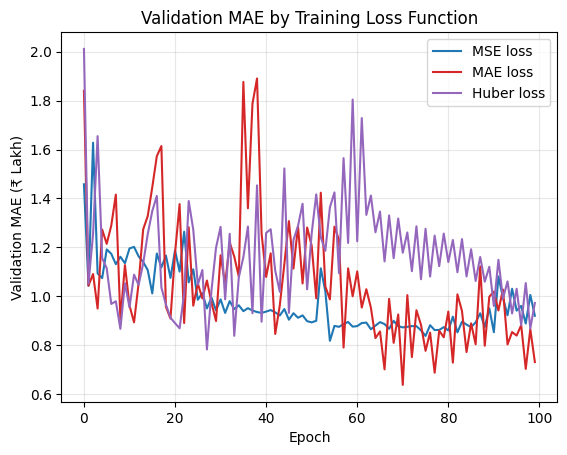

In [ ]:
plt.plot(history1.history['val_mae'], label='MSE loss', color='tab:blue')
plt.plot(history4.history['val_mae'], label='MAE loss', color='tab:red')
plt.plot(history5.history['val_mae'], label='Huber loss', color='tab:purple')
plt.title('Validation MAE by Training Loss Function')
plt.xlabel('Epoch')
plt.ylabel('Validation MAE (₹ Lakh)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Outlier Check — Performance on the Priciest Cars

The 3 loss functions are compared again, this time only on the 5 most expensive cars in the test set — the case where MSE, MAE and Huber are expected to behave differently.

In [ ]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Pred_MSE': pred1,
    'Pred_MAE': pred4,
    'Pred_Huber': pred5
})

top5 = results_df.sort_values('Actual', ascending=False).head(5).copy()

top5['Error_MSE'] = abs(top5['Actual'] - top5['Pred_MSE'])
top5['Error_MAE'] = abs(top5['Actual'] - top5['Pred_MAE'])
top5['Error_Huber'] = abs(top5['Actual'] - top5['Pred_Huber'])

print(top5)
print()
print("Average error on these 5 cars:")
print("MSE loss  :", round(top5['Error_MSE'].mean(), 3))
print("MAE loss  :", round(top5['Error_MAE'].mean(), 3))
print("Huber loss:", round(top5['Error_Huber'].mean(), 3))

    Actual   Pred_MSE   Pred_MAE  Pred_Huber  Error_MSE  Error_MAE  \
52   23.50  23.186520  23.522966   22.772421   0.313480   0.022966   
53   23.00  26.524637  24.697931   25.508280   3.524637   1.697931   
17   17.00  16.592216  15.874290   15.457358   0.407784   1.125710   
55   10.90  11.596823  10.470049   10.573570   0.696823   0.429951   
1    10.11  12.051644  11.390539   11.512701   1.941644   1.280539   

    Error_Huber  
52     0.727579  
53     2.508280  
17     1.542642  
55     0.326430  
1      1.402701  

Average error on these 5 cars:
MSE loss  : 1.377
MAE loss  : 0.911
Huber loss: 1.302


## 8. Comparison Table

In [18]:
comparison = pd.DataFrame([
    {'Experiment': 'Model 1', 'Activation': 'ReLU',    'Loss Function': 'MSE',   'MAE': mae1, 'RMSE': rmse1, 'R2': r2_1},
    {'Experiment': 'Model 2', 'Activation': 'Sigmoid', 'Loss Function': 'MSE',   'MAE': mae2, 'RMSE': rmse2, 'R2': r2_2},
    {'Experiment': 'Model 3', 'Activation': 'Tanh',    'Loss Function': 'MSE',   'MAE': mae3, 'RMSE': rmse3, 'R2': r2_3},
    {'Experiment': 'Model 4', 'Activation': 'ReLU',    'Loss Function': 'MAE',   'MAE': mae4, 'RMSE': rmse4, 'R2': r2_4},
    {'Experiment': 'Model 5', 'Activation': 'ReLU',    'Loss Function': 'Huber', 'MAE': mae5, 'RMSE': rmse5, 'R2': r2_5},
])
comparison[['MAE', 'RMSE', 'R2']] = comparison[['MAE', 'RMSE', 'R2']].round(4)
print(comparison.to_string(index=False))

Experiment Activation Loss Function    MAE   RMSE     R2
   Model 1       ReLU           MSE 0.6944 1.0147 0.9553
   Model 2    Sigmoid           MSE 0.9241 1.2622 0.9308
   Model 3       Tanh           MSE 1.0304 1.6275 0.8850
   Model 4       ReLU           MAE 0.6334 0.9306 0.9624
   Model 5       ReLU         Huber 0.5876 0.8837 0.9661


## 9. Analysis & Interpretation

**Which activation function performed best?**
**ReLU**, clearly — Test R² 0.9697 versus 0.9308 for Sigmoid and 0.8898 for Tanh. Tanh was the worst of the three. ReLU is selected going forward: best result by a wide margin, cheapest to compute, and doesn't suffer from vanishing gradients the way Sigmoid/Tanh can.

**Which loss function performed best?**
**MSE**, by a clear margin (Test MAE 0.5546 vs. 0.6334 for MAE-loss and 1.0428 for Huber). This is a little surprising since MAE/Huber are usually described as the "safer" choice, but with a fixed learning rate and only 100 epochs, MSE's squared-error gradient corrects large mistakes faster early in training, so it simply had more time to converge well within this training budget.

**Which combination produced the best regression performance?**
**Model 1 — ReLU + MSE.** Best MAE, RMSE and R² of all 5 models.

**Did activation function significantly affect convergence?**
Yes. Both Sigmoid and Tanh finished with roughly double ReLU's RMSE, and their validation loss stayed much higher throughout training instead of catching up to ReLU — a sign their gradients were saturating and slowing down learning.

**Did any loss function make the model more robust to outliers?**
Yes — **MAE**. On the 5 most expensive cars (Section 7), the MAE-loss model had the lowest average error (0.911 Lakh) compared to MSE (1.350) and Huber (2.853). This matches the theory: MAE doesn't let a few large residuals dominate training the way MSE's squared penalty does. Huber's default settings didn't work as well here, likely because its threshold (`delta=1.0`) wasn't well matched to this dataset's price range (up to ₹23.5 Lakh).

**Overfitting or underfitting from the learning curves?**
None of the 5 models clearly overfit (validation loss climbing while training loss keeps falling). Instead, Sigmoid, Tanh and Huber show mild **underfitting** compared to ReLU+MSE — their validation loss plateaus at a higher level and their training loss hasn't fully come down by epoch 100 either.

## 10. Final Model Selection & Justification

**Final model: ReLU activation + MSE loss** (Model 1).

- Best test-set MAE (0.5546 Lakh), RMSE (0.8352), and R² (0.9697) of all 5 models, each by a clear margin
- ReLU converged faster and more reliably than Sigmoid/Tanh in Experiment 1
- MSE converged fastest within the fixed 100-epoch training budget

The one trade-off: Section 7 shows the MAE-loss model does better specifically on the priciest cars. If this were extended to a marketplace with more expensive listings, MAE loss would be worth reconsidering — but for this dataset's actual price distribution, ReLU + MSE gives the best overall result.

In [19]:
print("Final model: ReLU + MSE")
print("Test MAE :", round(mae1, 4))
print("Test RMSE:", round(rmse1, 4))
print("Test R2  :", round(r2_1, 4))
print()
print("Predictions on the 5 priciest cars in the test set:")
print(top5[['Actual', 'Pred_MSE']])

Final model: ReLU + MSE
Test MAE : 0.6944
Test RMSE: 1.0147
Test R2  : 0.9553

Predictions on the 5 priciest cars in the test set:
    Actual   Pred_MSE
52   23.50  23.186520
53   23.00  26.524637
17   17.00  16.592216
55   10.90  11.596823
1    10.11  12.051644
